# Project: User Intent Classification on the Banking77 dataset

This notebook focuses on initial data loading, cleaning and **exploratory data analysis (EDA)**. Our aim is to understand the structure of the dataset, the class distribution and the linguistic features of the texts for the subsequent training of CatBoost and BERT models.

# Analysis of job profiles and definition of project objectives

Before development began, an analysis was carried out of three current vacancies for the role of **NLP / Machine Learning Engineer (Middle)** in the financial technology (FinTech) sector:

1. **ML Engineer (Monobank / Fintech)** — Requirements: experience working with transformers (BERT, RoBERTa), text classification, and optimising models for inference.
2. **Data Scientist (Preply / NLP specialism)** — Requirements: working with embeddings (Sentence Transformers), PyTorch, model validation, and deploying models via API.
3. **Machine Learning Engineer (Ukrsibbank / AI Support)** — Requirements: analysis of logs and user queries, experience with classical algorithms (CatBoost) and neural networks for support automation.

### Key findings from the market analysis:
* **Most in-demand skills:** Understanding of the Transformers architecture, proficiency with the PyTorch framework, ability to work with dense vectors (embeddings), error analysis skills, and optimising models for limited resources (production constraints).
* **Types of tasks:** Automating the processing of customer enquiries, classifying the intents of text messages, and building support chatbots.

### The aim of my project:
Based on an analysis of job vacancies, in this project I aim to demonstrate the following skills:
1. Building a complete NLP pipeline: from a basic statistical baseline to state-of-the-art (SOTA) transformers.
2. Working with modern embedded architectures and the PyTorch framework on a real-world FinTech dataset comprising 77 classes.
3. Making engineering trade-offs (speed versus accuracy) when selecting a model for deployment under strict cloud server constraints.

## Importing libraries and configuration

In [1]:
# Automatic reloading of modules whilst editing
%load_ext autoreload
%autoreload 2

# Basic libraries and data handling
import os
import sys
import warnings
import pandas as pd
from datasets import load_dataset

# Visualization and text analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Adding the project root to sys.path for importing custom modules from the src folder
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Model validation
from sklearn.model_selection import train_test_split  # noqa: E402
from src.preprocessing import plot_top_ngrams, create_wordcloud  # noqa: E402

# Suppressing unnecessary warnings for a more compact output during training/experiments.
warnings.filterwarnings("ignore")

## 1. Loading and initial review of the data

At this stage, we check for the presence of local files in the `data` folder. If none are found, we download the original `mteb/banking77` dataset via the Hugging Face library, convert it to a Pandas DataFrame and save it as a CSV file for quick local access without an internet connection.

In [2]:
# Loading or reading the data
data_dir = "../data"
os.makedirs(data_dir, exist_ok=True)

train_path = os.path.join(data_dir, "banking77_train.csv")
test_path = os.path.join(data_dir, "banking77_test.csv")

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("File not found. Downloading...")
    raw_dataset = load_dataset("mteb/banking77")
    train_df = pd.DataFrame(raw_dataset["train"])
    test_df = pd.DataFrame(raw_dataset["test"])

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)
    print("Downloaded successfully!")
else:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    print("File already exists.")

# Checking the dimensions and data types
print(f"Train DataFrame shape: {train_df.shape}")
print(f"Test DataFrame shape: {test_df.shape}")

print("--- Train DataFrame info ---")
train_df.info()

print("\n--- Test DataFrame info ---")
test_df.info()

# Displaying the first rows for a visual check
print("\nThe first 5 rows of the dataset:")
train_df.head()

File already exists.
Train DataFrame shape: (9993, 3)
Test DataFrame shape: (3076, 3)
--- Train DataFrame info ---
<class 'pandas.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        9993 non-null   str  
 1   label       9993 non-null   int64
 2   label_text  9993 non-null   str  
dtypes: int64(1), str(2)
memory usage: 1021.3 KB

--- Test DataFrame info ---
<class 'pandas.DataFrame'>
RangeIndex: 3076 entries, 0 to 3075
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        3076 non-null   str  
 1   label       3076 non-null   int64
 2   label_text  3076 non-null   str  
dtypes: int64(1), str(2)
memory usage: 296.6 KB

The first 5 rows of the dataset:


,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


### Key characteristics of the dataset:
* **`text`** (type `str`) — the raw text of the customer’s message (input feature).
* **`label`** (type `int64`) — a numeric class identifier (target for models).
* **`label_text`** (type `str`) — a human-readable description of the intent (e.g., `card_arrival`).

## 2. Target Distribution

For text classification tasks (particularly those with a large number of classes, such as our case — 77), it is crucial to check the balance of the sample. This determines the validation strategy and the choice of model evaluation metrics.

The top 5 and rarest classes in Train:
label_text
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64


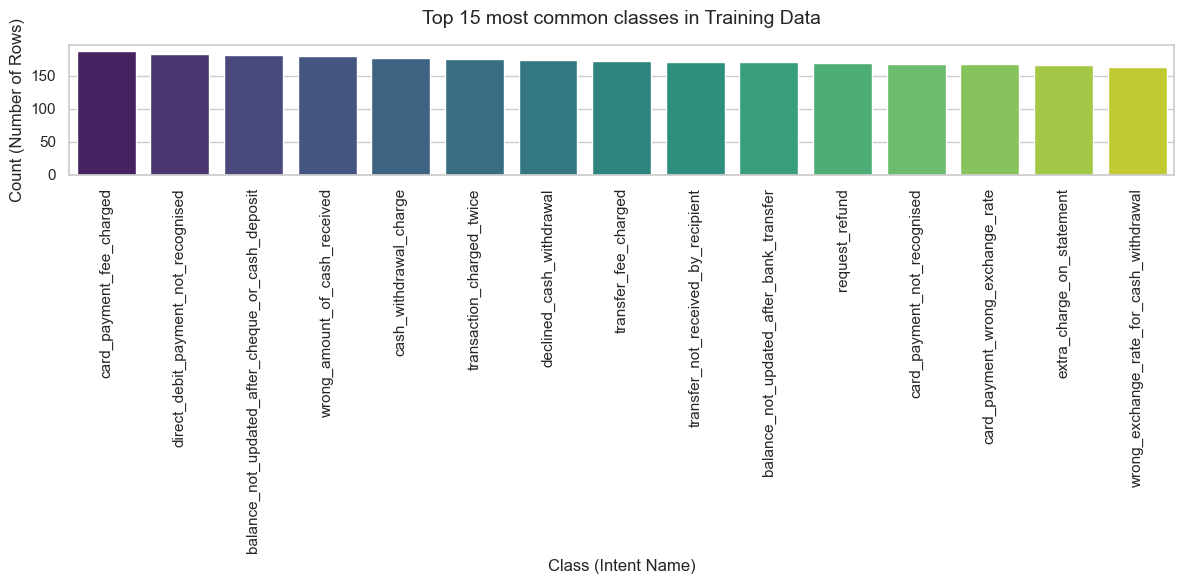

In [3]:
# Calculating the class distribution
print("The top 5 and rarest classes in Train:")
print(train_df["label_text"].value_counts())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Visualizing the top 15 most common categories
top_classes = train_df["label_text"].value_counts().head(15)
sns.barplot(
    x=top_classes.index,
    y=top_classes.values,
    palette="viridis",
    hue=top_classes.index,
    legend=False,
)
plt.title("Top 15 most common classes in Training Data", fontsize=14, pad=15)
plt.xlabel("Class (Intent Name)", fontsize=12)
plt.ylabel("Count (Number of Rows)", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Conclusions regarding class distribution:
1. The dataset contains exactly **77 unique classes**.
2. There is a moderate class imbalance: the most common intents have around 180–187 examples (e.g. `card_payment_fee_charged`), whilst the rarest have around 35 examples (`contactless_not_working`). The difference is approximately a factor of 5.
3. **Impact on the ML pipeline:** * When splitting the data into Train and Validation sets, we must use stratification (`stratify`) to preserve the class proportions.
4. **Importance of metric selection:** Due to the class imbalance, the classic Accuracy metric cannot be used, as it can be deceptive by favoring majority classes at the expense of rare ones. We will evaluate the final quality of the models using the **Macro F1-score** (as the primary metric, which treats all 77 classes with equal importance and accounts for performance on both common and rare classes) and **ROC-AUC** (to assess the model’s ability to rank intent probabilities). In addition, we will monitor the **Weighted F1-score** to assess the overall accuracy of the system, taking data volumes into account.

## 3. Analysis of text message length (Word Count EDA)

We analyse the number of words in customer queries for the Train and Test datasets. This will help us determine the optimal sequence length (`max_length`) for transformer tokenisation (BERT) and understand the text density for linear models or gradient boosting.

In [4]:
# We count the number of words in each message to subsequently determine the optimal `max_length` for BERT
train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))
print("Statistics for word count training data:\n")
print(train_df["word_count"].describe())

test_df["word_count"] = test_df["text"].apply(lambda x: len(x.split()))
print("\nStatistics for word count test data:\n")
print(test_df["word_count"].describe())


Statistics for word count training data:

count    9993.000000
mean       11.955369
std         7.891187
min         3.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        79.000000
Name: word_count, dtype: float64

Statistics for word count test data:

count    3076.000000
mean       10.963264
std         6.685814
min         3.000000
25%         7.000000
50%         9.000000
75%        12.000000
max        69.000000
Name: word_count, dtype: float64


### Findings regarding text length:
* **Train sample:** The average query length is **~12 words**, the median (50%) is **10 words**. 75% of all messages do not exceed **13 words**. However, there is one abnormally long query of **79 words**.
* **Test set:** The statistics are identical (mean — **~11 words**, 75th percentile — **12 words**, maximum — **69 words**). This confirms that the test split has the same linguistic distribution as the training set.
* **Impact on the ML pipeline:** The texts are very short and concise. For the BERT model, there is absolutely no point in setting the standard `max_length=512`. A value of `max_length=64` (or even 32) will cover 99% of the data. This will save gigabytes of RAM on a Mac and speed up neural network training significantly!

## 4. Checking for missing values and duplicates (Data Cleaning & Quality Check)

Before starting to build models, it is essential to check data quality (data hygiene). Missing values (`NaN`) can disrupt model training, whilst duplicates in text (particularly those with different labels) can lead to distorted metrics and overfitting (data leakage).

In [ ]:
# We check the quality of the data before modelling: are there any missing values in the train/test sets?
print(f"Missing values train:\n{train_df.isnull().sum()}\n")
print(f"Missing values test:\n{test_df.isnull().sum()}\n")

# We check for fully duplicated rows to avoid distorted metrics
print(f"Duplicated rows train:\n{train_df.duplicated().sum()}\n")
print(f"Duplicated rows test:\n{test_df.duplicated().sum()}\n")

# We also check for duplicates in the text itself (even if other fields may differ)
print(f"Duplicate in text train:\n{train_df['text'].duplicated().sum()}\n")
print(f"Duplicate in text test:\n{test_df['text'].duplicated().sum()}\n")

Missing values train:
text          0
label         0
label_text    0
word_count    0
dtype: int64

Missing values test:
text          0
label         0
label_text    0
word_count    0
dtype: int64

Duplicated rows train:
0

Duplicated rows test:
0

Dublicate in text train:
0

Dublicate in text test:
0



### Conclusions regarding data quality:
1. **Missing Values:** In both datasets (`Train` and `Test`), there are **absolutely no** missing values (0 `Null/NaN` values). All text fields and labels are filled in correctly.
2. **Duplicates:** * Complete duplicate rows (text + label) — **0**.
   * Duplicates in the `text` column only — **0**.
3. **Overall summary:** The `mteb/banking77` dataset has exceptionally high-quality initial annotation. We do not need to carry out any deduplication or missing value filling procedures. The data is fully ready to be split into validation samples.

## 5. In-depth NLP analysis of texts (N-grams & Text Mining)

To understand the semantics of customer enquiries, we will analyse the most frequent word combinations (bigrams and trigrams). This will enable us to identify key markers for each intent even before the model training stage. To ensure the purity of the analysis, we will exclude common stop words (articles, conjunctions) directly during the calculation.

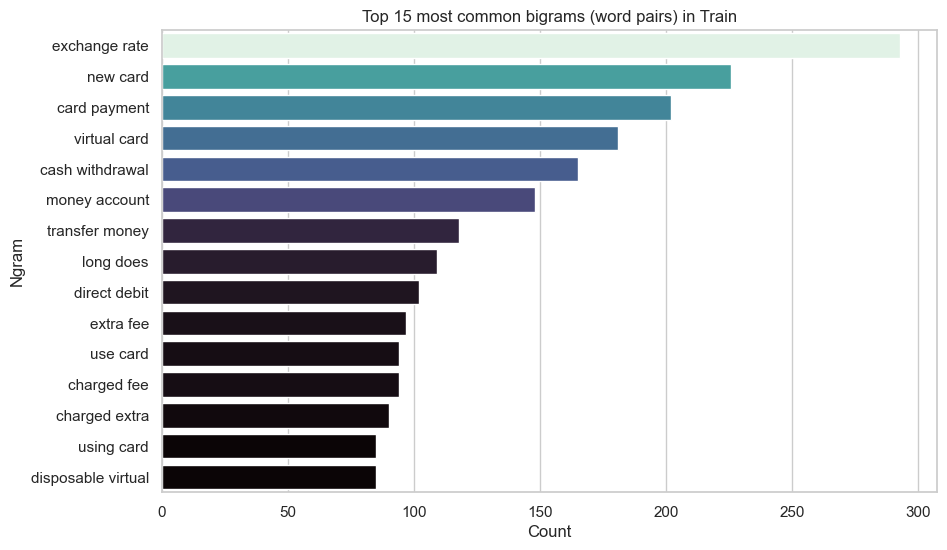

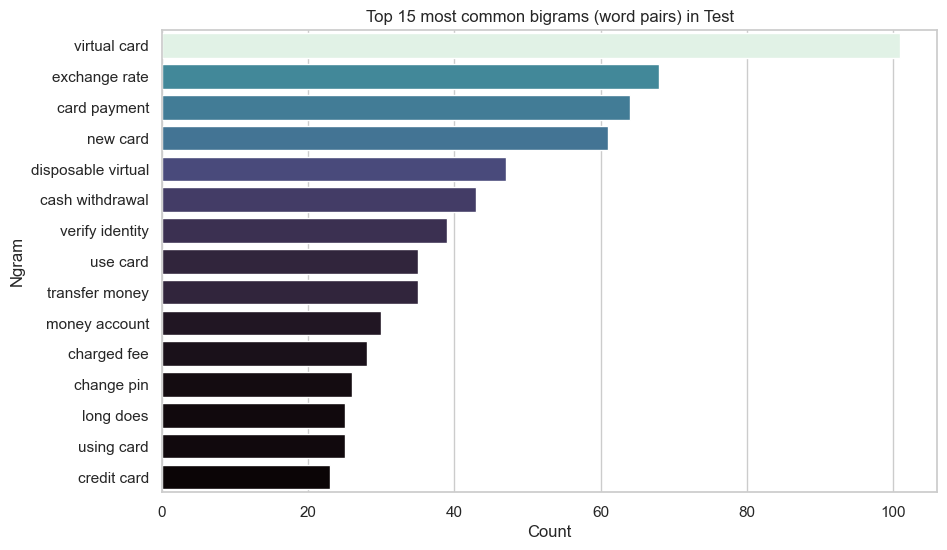

In [ ]:
# Comparing the most frequent bigrams in Train and Test to check the representativeness of the samples
plot_top_ngrams(
    train_df["text"], title="Top 15 most common bigrams (word pairs) in Train"
)
plot_top_ngrams(
    test_df["text"], title="Top 15 most common bigrams (word pairs) in Test"
)

### Conclusions regarding the N-gram analysis:

To understand the semantic content of customer enquiries, a bigram (word pairs) analysis was carried out on the training and test datasets. English stop words (`the`, `and`, `is`, etc.) were excluded in order to focus exclusively on meaningful phrases.

1. **Identity of distributions:** The top phrases in `Train` (e.g. `exchange rate`, `new card`, `card payment`, `cash withdrawal`) are almost perfectly replicated in `Test`. This indicates that the split into samples is representative, and the model will not encounter unexpected linguistic expressions during validation.
2. **Domain specificity:** The phrases have a clear financial connotation. This means that the texts have a high density of useful features, which is critically important for both classical linear models and transformers (BERT).

## 6. Analysis of message length by category (Box Plot Analysis)

To check whether message length depends on a specific customer issue, we will plot a box plot for the top 10 most popular categories. This allows us to compare the median, quantiles and outliers for each individual intent.

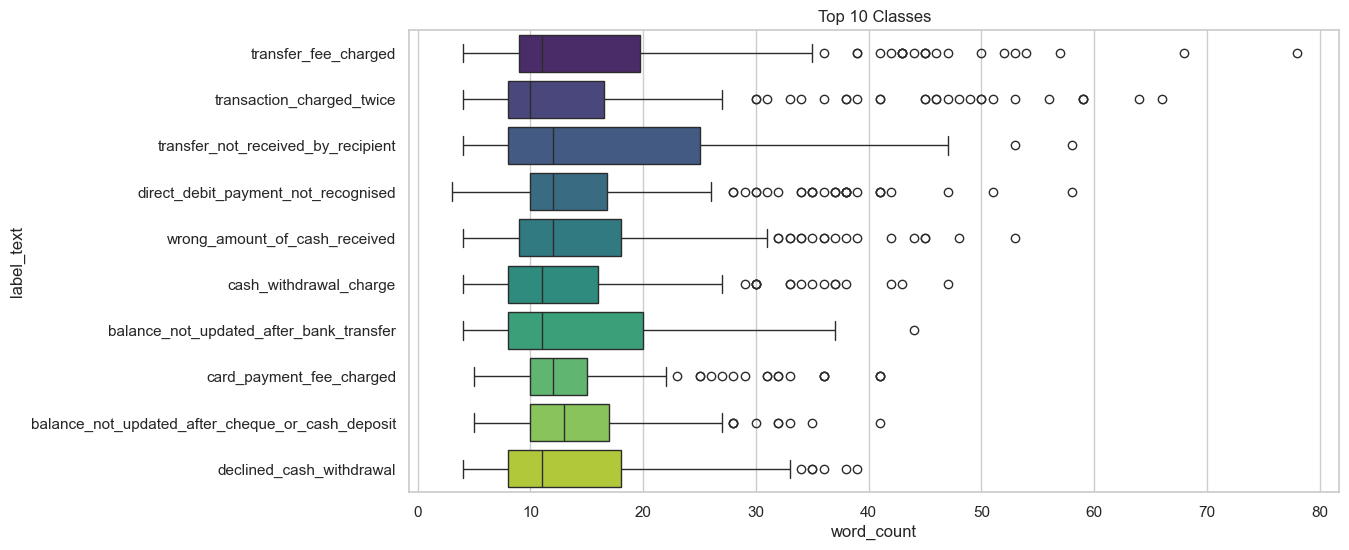

In [ ]:
# Determining the top 10 most frequent classes to keep the comparison focused and readable
top_10_classes = train_df["label_text"].value_counts().head(10).index

# Creating a subset for these classes and sorting for easier analysis of long messages
sub_df = train_df[train_df["label_text"].isin(top_10_classes)].sort_values(
    "word_count", ascending=False
)

# Building a boxplot to compare the distribution of text lengths among the most popular intents
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="word_count",
    y="label_text",
    data=sub_df,
    palette="viridis",
    hue="label_text",
    legend=False,
)
plt.title("Top 10 Classes")
plt.show()

### Conclusions from the box plot analysis:
1. **Median stability:** The median message length (the vertical line inside the ‘boxes’) for all top categories is very stable and fluctuates around **10–12 words**. Customers formulate their enquiries with roughly the same level of conciseness, regardless of the topic (whether it’s a transfer fee `transfer_fee_charged` or problems with an ATM `declined_cash_withdrawal`).
2. **Analysis of long-tail outliers:** The graph clearly shows ‘points’ to the right of the whiskers — these are abnormally long messages (ranging from 30 to 80 words). Users tend to write the longest descriptions (up to 79 words) in the `transfer_fee_charged` and `transaction_charged_twice` categories. This makes sense: when a customer is charged twice or an unclear fee is deducted, they are likely to describe the background in detail, emotionally and at length.
3. **Impact on the ML pipeline:** As there is no critical difference in the ‘box’ geometry between the classic categories (the distributions are very similar), sentence length (`word_count`) alone cannot serve as a strong distinguishing marker for the models. Future models (Boosts, BERT) will therefore have to focus primarily on semantics and keywords.

## 7. Keyword Visualisation (Word Cloud Comparison)

To provide a visual representation of the semantic content of different intents, word clouds were generated for two polar classes: the most popular (`card_payment_fee_charged`) and the rarest (`contactless_not_working`). During generation, an extended list of stop words (English articles, the verbs `want`, `need`, `make` and the greeting `hello`) was used to highlight exclusively domain-specific financial terms.

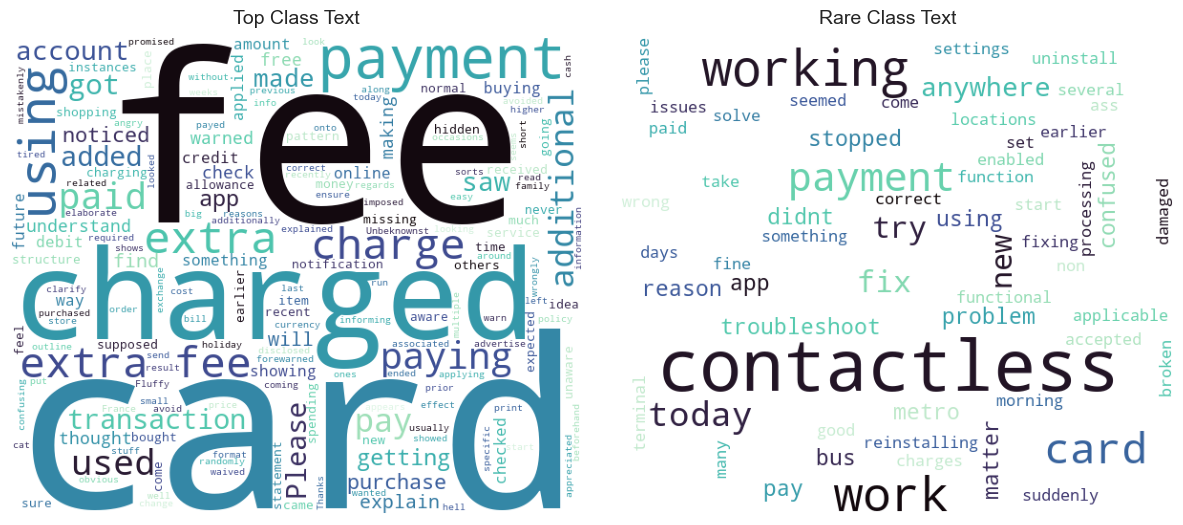

In [ ]:
# Collecting texts for visualization
top_class_text = " ".join(
    train_df[train_df["label_text"] == "card_payment_fee_charged"]["text"]
)
rare_class_text = " ".join(
    train_df[train_df["label_text"] == "contactless_not_working"]["text"]
)

# Visualizing the two word clouds side by side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
create_wordcloud(top_class_text, "Top Class Text")

plt.subplot(1, 2, 2)
create_wordcloud(rare_class_text, "Rare Class Text")

plt.tight_layout()
plt.show()

### Conclusions from the comparison of word clouds:
1. **Quality of distributions:** The difference between the word clouds is enormous. The left-hand cloud (`card_payment_fee_charged`) is dominated by the words `charged`, `fee`, `card` and `payment`. The right-hand cloud (`contactless_not_working`) contains clear markers such as `payment`, `contactless`, `stopped`, `not` and `working`.
2. **Markers for models:** This confirms our hypothesis that keywords are strong discriminating features. Simple linear models (such as logistic regression), using TF-IDF vectorisation, will be able to easily classify these queries based on the presence of 2–3 key tokens.

## 8. Data preparation: Stratified split (Train/Validation Split)

Before moving on to the model training stage, the original dataset must be split into a training (`Train`) and a validation (`Validation`) set. The validation set is necessary for tuning hyperparameters and controlling overfitting, so as not to use the final test set prematurely.

### Approach to splitting:
* **Proportion (80/20):** 20% of the data is set aside for validation (`test_size=0.2`), which is standard practice for datasets of this size.
* **Stratification (`stratify=train_df['label']`):** A critically important parameter due to the detected class imbalance. It ensures that the `Train` and `Validation` samples retain an absolutely identical percentage distribution for each of the 77 classes.
* **Reproducibility (`random_state=42`):** Fixing the random number generator ensures that the partitioning will be identical every time the laptop is restarted.

In [ ]:
# Performing a stratified split of the train set into train/validation
train_df_final, val_df_final = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["label"]
)

# Checking the shapes of the splits to quickly verify that the split was performed as expected.
print(f"Train shape: {train_df_final.shape}")
print(f"Val shape: {val_df_final.shape}")

Train shape: (7994, 4)
Val shape: (1999, 4)


In [ ]:
# Serializing all three final splits to disk for use in subsequent notebooks
train_df_final.to_csv("../data/train_split.csv", index=False)
val_df_final.to_csv("../data/val_split.csv", index=False)
test_df.to_csv("../data/test_split.csv", index=False)
print("Data saved successfully!")

Data saved successfully!


### Saving the results of exploratory data analysis (EDA)
All three resulting dataframes have been successfully serialised and saved to the local project directory in accordance with the target structure:
* `data/train_split.csv` — a clean training set for vectorisation and model training (7,994 rows).
* `data/val_split.csv` — a validation set for evaluating interim experiments (1,999 rows).
* `data/test_split.csv` — a final test set for independently assessing the quality of the final model.

At this stage, the **Exploratory Data Analysis (EDA)** and initial data preparation are fully complete. The data has been cleaned, checked for imbalance, visualised and saved. We are now ready to open the next notebook, `02_baseline.ipynb`, to carry out feature engineering (TF-IDF) and build the first baseline model.

## 9. Overall Summary of the Exploratory Data Analysis (Global EDA Summary)

Although the dataset contains clear lexical markers, some classes may prove challenging for the model due to similarities in phrasing. For example, enquiries about fees, transfers or card issues may have overlapping vocabulary. This is particularly important for short messages, where the model must rely on a few keywords rather than a broad context.

The exploratory data analysis conducted for the `mteb/banking77` dataset has provided a comprehensive understanding of the structure and specific characteristics of customers’ text enquiries. 

### Key engineering insights:
1. **High data quality:** The dataset contains no missing values (`NaN`) or complete duplicate rows. The initial quality of the data collection is exceptionally high, eliminating the need for a complex deduplication and imputation stage.
2. **Quality of text content:** The average message length is **10–12 words**. Boxplot analysis showed that the distribution of message lengths is uniform across different intents. Text length alone is not a strong discriminating feature — models will have to rely solely on semantics.
3. **Pronounced semantic specificity (N-grams & Word Clouds):** The highlighted bigrams (`exchange rate`, `card payment`) and word clouds clearly distinguish the classes from one another. The vocabulary is highly specific to each individual intent.
4. **Representativeness of samples:** The distribution of top bigrams in the `Train` and `Test` sets is almost identical. This ensures that the results on the validation and test sets will be accurate and reflect the true quality of the models.

### Implications for the modelling phase (Next Steps):
* **Class imbalance:** As we identified an uneven distribution across the 77 classes, **stratification (`stratify`)** was applied when splitting the data into `Train/Validation`. In our model evaluation metrics, we will focus on the **Macro F1-Score** and will also monitor the **Weighted F1-Score** and **ROC-AUC**, rather than basic Accuracy.
* **Baseline potential:** The presence of distinct key tokens suggests that simple models (Logistic Regression / Boosting + TF-IDF) will get off to a decent start.
* **BERT potential:** As the texts are written in the customers’ natural language (retaining context, specific prepositions and financial entities), transformer models (e.g. `BERT` or `DistilBERT`) have good potential to achieve high accuracy.
* **Hypothesis for the next stage:** At this stage, we can formulate a basic hypothesis: simple TF-IDF-based models are likely to provide a strong baseline, whilst transformer-based approaches may deliver even better results thanks to their superior handling of context and query semantics.